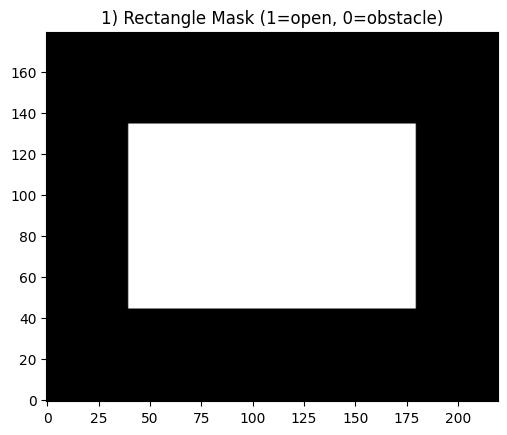

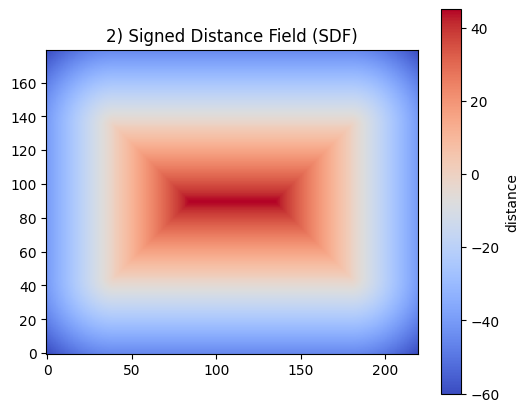

3) Energy (soft intrusion penalty) = 2.7423
4) before E=3.7977, after E=2.9225, gain=0.8753, ok=True


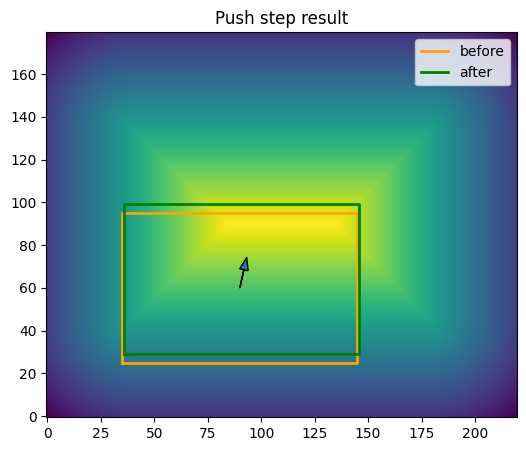

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt as edt

# -----------------------------
# 1. make_rectangle_mask
# -----------------------------
def make_rectangle_mask(nx=220, ny=180, rect_w=140, rect_h=90):
    """
    사각형 모양의 open space (1=open, 0=obstacle) 마스크 생성
    """
    m = np.zeros((ny, nx), dtype=np.uint8)
    cx, cy = nx // 2, ny // 2
    x0, x1 = cx - rect_w // 2, cx + rect_w // 2
    y0, y1 = cy - rect_h // 2, cy + rect_h // 2
    m[y0:y1, x0:x1] = 1
    return m

# 예제 실행
mask = make_rectangle_mask()
plt.imshow(mask, origin="lower", cmap="gray")
plt.title("1) Rectangle Mask (1=open, 0=obstacle)")
plt.show()

# -----------------------------
# 2. signed_distance
# -----------------------------
def signed_distance(open_mask):
    """
    open_mask: 1=open, 0=obstacle
    반환값: sdf (open 내부 +, obstacle 내부 -)
    """
    open_mask = (open_mask > 0).astype(np.uint8)
    inside = edt(open_mask)          # open 내부에서 obstacle까지 거리
    outside = edt(1 - open_mask)     # obstacle 내부에서 open까지 거리
    sdf = inside - outside
    return sdf.astype(np.float32)

# 예제 실행
sdf = signed_distance(mask)
plt.figure(figsize=(6,5))
plt.title("2) Signed Distance Field (SDF)")
plt.imshow(sdf, origin="lower", cmap="coolwarm")
plt.colorbar(label="distance")
plt.show()

# -----------------------------
# 3. energy_simple
# -----------------------------
def bilinear_sample(arr, pts_xy):
    """
    arr: (H,W), pts_xy: (N,2) with (x,y)
    """
    H, W = arr.shape
    x = pts_xy[:,0]
    y = pts_xy[:,1]

    x0 = np.clip(np.floor(x).astype(int), 0, W-1)
    x1 = np.clip(x0 + 1, 0, W-1)
    y0 = np.clip(np.floor(y).astype(int), 0, H-1)
    y1 = np.clip(y0 + 1, 0, H-1)

    dx = x - x0
    dy = y - y0

    v00 = arr[y0, x0]
    v01 = arr[y1, x0]
    v10 = arr[y0, x1]
    v11 = arr[y1, x1]

    v0 = v00*(1-dx) + v10*dx
    v1 = v01*(1-dx) + v11*dx
    v  = v0*(1-dy) + v1*dy
    return v

def sample_bbox_perimeter(cx, cy, w, h, samples_per_side=40):
    """
    축 회전 없는 BBox의 테두리 샘플
    """
    hw, hh = w/2, h/2
    pts = []
    # 아래, 위, 좌, 우
    xs = np.linspace(cx-hw, cx+hw, samples_per_side)
    ys = np.linspace(cy-hh, cy+hh, samples_per_side)
    for x in xs:
        pts.append([x, cy-hh])
        pts.append([x, cy+hh])
    for y in ys:
        pts.append([cx-hw, y])
        pts.append([cx+hw, y])
    return np.array(pts)

def energy_simple(open_mask, sdf, box_params):
    """
    단순 침범 정도 측정:
      E = 평균 softplus(-d/tau)
    """
    cx, cy, w, h = box_params
    pts = sample_bbox_perimeter(cx, cy, w, h, samples_per_side=60)
    d = bilinear_sample(sdf, pts)
    tau = 2.0
    penalty = np.mean(np.log1p(np.exp(-(d / tau))))
    return penalty

# 예제 실행
box = (80, 70, 100, 70)
E = energy_simple(mask, sdf, box)
print(f"3) Energy (soft intrusion penalty) = {E:.4f}")

# -----------------------------
# 4. backtracking_push_step
# -----------------------------
def sdf_gradient(sdf):
    gy, gx = np.gradient(sdf)
    return gx, gy

def push_direction_from_sdf(sdf, pts_xy, tau=2.0):
    gx, gy = sdf_gradient(sdf)
    d_vals = bilinear_sample(sdf, pts_xy)
    gx_vals = bilinear_sample(gx, pts_xy)
    gy_vals = bilinear_sample(gy, pts_xy)

    w = np.zeros_like(d_vals)
    w[d_vals < 0] = 1.0 + (-d_vals[d_vals < 0])
    near = (d_vals >= 0) & (d_vals < tau)
    w[near] = (tau - d_vals[near]) / tau

    if np.all(w == 0):
        return np.zeros(2, dtype=np.float32)

    vx = np.sum(w * gx_vals) / np.sum(w)
    vy = np.sum(w * gy_vals) / np.sum(w)
    return np.array([vx, vy], dtype=np.float32)

def backtracking_push_step(open_mask, sdf, box_params, init_step=5.0, beta=0.5, c=1e-3, max_tries=10):
    """
    push 방향으로 이동하되, 에너지가 줄어드는 경우만 수용(Armijo)
    """
    cx, cy, w, h = box_params
    pts = sample_bbox_perimeter(cx, cy, w, h, samples_per_side=60)
    v = push_direction_from_sdf(sdf, pts, tau=2.0)
    if np.allclose(v, 0):
        return box_params, False, 0.0, v

    E0 = energy_simple(open_mask, sdf, box_params)
    step = init_step
    for _ in range(max_tries):
        cand = (cx + step*v[0], cy + step*v[1], w, h)
        E1 = energy_simple(open_mask, sdf, cand)
        if E1 <= E0 - c * step * np.linalg.norm(v):
            return cand, True, (E0 - E1), v
        step *= beta

    return box_params, False, 0.0, v

# 예제 실행
box = (90.0, 60.0, 110.0, 70.0)
E0 = energy_simple(mask, sdf, box)
box2, ok, gain, v = backtracking_push_step(mask, sdf, box)
E1 = energy_simple(mask, sdf, box2)

print(f"4) before E={E0:.4f}, after E={E1:.4f}, gain={gain:.4f}, ok={ok}")

plt.figure(figsize=(7,5))
plt.imshow(sdf, origin="lower")
plt.title("Push step result")
# 초기 / 최종 박스 시각화
def draw_box(b, color):
    cx, cy, w, h = b
    hw, hh = w/2, h/2
    xs = [cx-hw, cx+hw, cx+hw, cx-hw, cx-hw]
    ys = [cy-hh, cy-hh, cy+hh, cy+hh, cy-hh]
    plt.plot(xs, ys, color=color, lw=2)
draw_box(box, "orange")
draw_box(box2, "green")
plt.arrow(box[0], box[1], v[0]*10, v[1]*10, head_width=4.0)
plt.legend(["before", "after"])
plt.show()
